In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow, RBackflow
from detnqs.vstate import MCState
from detnqs.sampler import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import psr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("single")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [3]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(10)]),
    basis="sto-6g",
    unit="Angstrom",
    verbose=0,
)

mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Pure Löwdin OAO / site basis.
S = mol.intor_symmetric("int1e_ovlp")
C = lo.orth.orth_ao(mol, method="lowdin", pre_orth_ao=None)
assert np.allclose(C.T @ S @ C, np.eye(norb), atol=1e-10)

h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), norb)

h1e[np.abs(h1e) < 1e-6] = 0.0
eri[np.abs(eri) < 1e-6] = 0.0

# RHF reference expressed in OAO basis.
mo_oao = np.linalg.solve(C, mf.mo_coeff)
assert np.allclose(mo_oao.T @ mo_oao, np.eye(norb), atol=1e-10)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_oao[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_oao[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -7.66652801326695

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -3.999817969532
FCI energy : -4.790991828654
S^2  : 0.000000


In [ ]:
model = RBackflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    proposal="ham",
    blur=0.5,
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    psr(shift=1e-3),
    optax.scale(-5e-2)
)

steps = 1000

--------------------------------------------------------------------------------------------------------
Step        Energy         |E-E0|       Var        Acc      ESS      N_u      N_f     alpha    SR cond  
--------------------------------------------------------------------------------------------------------


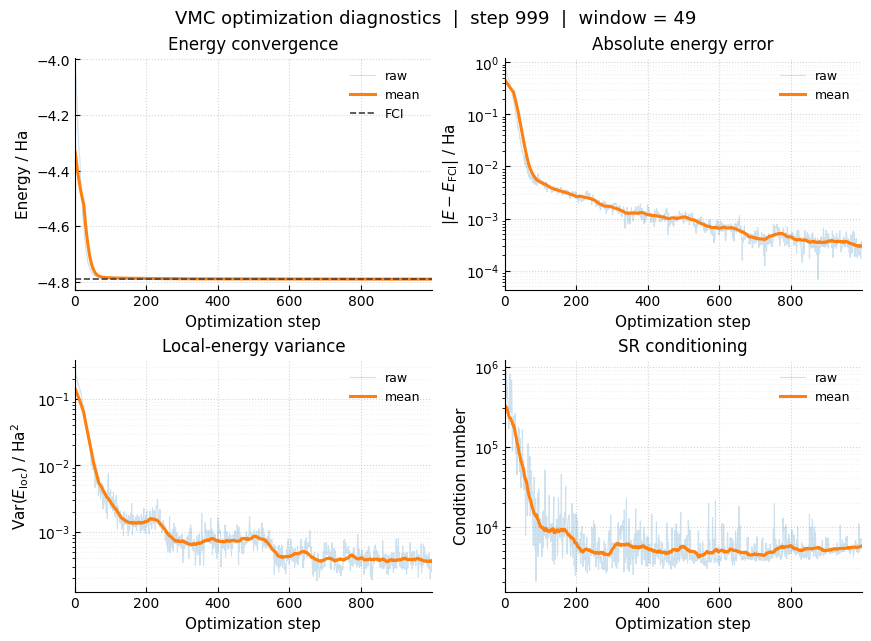

  0      -3.99669480      7.94e-01    2.84e-01    78.2%    52.2%     964     30353    1.000    5.14e+04 
 10      -4.26909590      5.22e-01    1.59e-01    54.8%    81.7%     944     28246    1.840    3.63e+05 
 20      -4.50847197      2.83e-01    9.48e-02    36.2%    78.1%     839     24986    1.901    6.76e+05 
 30      -4.66537619      1.26e-01    4.49e-02    28.5%    68.1%     749     21910    1.885    2.63e+05 
 40      -4.74451590      4.65e-02    2.08e-02    22.5%    61.8%     656     19358    1.840    1.45e+05 
 50      -4.77247000      1.85e-02    8.70e-03    18.0%    58.5%     579     17699    1.789    1.63e+05 
 60      -4.78029013      1.07e-02    6.60e-03    15.1%    56.3%     562     16588    1.730    3.30e+04 
 70      -4.78372574      7.27e-03    3.94e-03    15.5%    52.8%     555     16435    1.670    2.66e+04 
 80      -4.78485537      6.14e-03    4.92e-03    16.6%    51.2%     548     16176    1.610    6.06e+03 
 90      -4.78609610      4.90e-03    2.93e-03    18.4%

In [6]:
from collections import defaultdict
from IPython.display import display

METRICS = {
    "step":     ("Step",    "d",    5),
    "energy":   ("Energy",  ".8f", 16),
    "error":    ("|E-E0|", ".2e", 10),
    "variance": ("Var",    ".2e", 10),
    "accept":   ("Acc",    ".1%",  7),
    "ess_frac": ("ESS",    ".1%",  7),
    "n_unique": ("N_u",    ".0f",  7),
    "n_eval":   ("N_f",    ".0f",  7),
    "alpha":    ("alpha",  ".3f",  7),
    "sr_cond":  ("SR cond", ".2e", 10),
}

header = "  ".join(f"{label:^{width}}" for label, _, width in METRICS.values())
line = "-" * len(header)
print(line, header, line, sep="\n")


# ----------------------------------------------------------------------
# Online figure
# ----------------------------------------------------------------------
plot_every = 10
max_window = 50

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.3), constrained_layout=True)
axes = axes.ravel()

energy_raw, = axes[0].plot([], [], lw=0.8, alpha=0.22, label="raw")
energy_avg, = axes[0].plot([], [], lw=2.2, label="mean")
axes[0].axhline(e_fci, ls="--", lw=1.2, color="0.25", label="FCI")
axes[0].set(title="Energy convergence", xlabel="Optimization step", ylabel="Energy / Ha")

error_raw, = axes[1].plot([], [], lw=0.8, alpha=0.22, label="raw")
error_avg, = axes[1].plot([], [], lw=2.2, label="mean")
axes[1].set_yscale("log")
axes[1].set(title="Absolute energy error", xlabel="Optimization step",
            ylabel=r"$|E - E_\mathrm{FCI}|$ / Ha")

var_raw, = axes[2].plot([], [], lw=0.8, alpha=0.22, label="raw")
var_avg, = axes[2].plot([], [], lw=2.2, label="mean")
axes[2].set_yscale("log")
axes[2].set(title="Local-energy variance", xlabel="Optimization step",
            ylabel=r"$\mathrm{Var}(E_\mathrm{loc})$ / Ha$^2$")

cond_raw, = axes[3].plot([], [], lw=0.8, alpha=0.22, label="raw")
cond_avg, = axes[3].plot([], [], lw=2.2, label="mean")
axes[3].set_yscale("log")
axes[3].set(title="SR conditioning", xlabel="Optimization step", ylabel="Condition number")

for ax in axes:
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, which="major", ls=":", alpha=0.55)
    ax.grid(True, which="minor", ls=":", alpha=0.18)
    ax.tick_params(labelsize=10, direction="in")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.title.set_size(12)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)

fig.suptitle("VMC optimization diagnostics", fontsize=13)

display_handle = display(fig, display_id=True)
plt.close(fig)


# ----------------------------------------------------------------------
# VMC optimization
# ----------------------------------------------------------------------
vmc = VMC.init(state, optimizer)
history = []
total_times = defaultdict(float)

for step in range(steps):
    stats = dict(vmc.step())
    stats["step"] = step
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(stats)

    for key, value in stats.items():
        if key.startswith("time_"):
            total_times[key.removeprefix("time_")] += float(value)

    if step % 10 == 0 or step == steps - 1:
        row = []
        for key, (_, fmt, width) in METRICS.items():
            value = stats.get(key, np.nan)
            text = f"{int(value):{fmt}}" if fmt == "d" else f"{float(value):{fmt}}"
            row.append(f"{text:^{width}}")
        print("  ".join(row))

    if step % plot_every == 0 or step == steps - 1:
        hist = {
            key: np.asarray([record.get(key, np.nan) for record in history], dtype=float)
            for key in METRICS
        }

        mask = hist["step"] > 0
        x = hist["step"][mask]

        if len(x):
            e = hist["energy"][mask]
            err = np.clip(hist["error"][mask], 1e-16, None)
            var = np.where(hist["variance"][mask] > 0, hist["variance"][mask], np.nan)
            cond = np.where(hist["sr_cond"][mask] > 0, hist["sr_cond"][mask], np.nan)

            window = min(max_window, max(5, 2 * (len(x) // 40) + 1))
            kernel = np.ones(window)

            valid = np.isfinite(e)
            e_mean = np.convolve(np.where(valid, e, 0.0), kernel, mode="same")
            e_norm = np.convolve(valid.astype(float), kernel, mode="same")
            e_mean = e_mean / np.maximum(e_norm, 1.0)
            e_mean[e_norm == 0] = np.nan
            err_mean = np.clip(np.abs(e_mean - e_fci), 1e-16, None)

            log_var = np.log(var)
            valid = np.isfinite(log_var)
            var_mean = np.convolve(np.where(valid, log_var, 0.0), kernel, mode="same")
            var_norm = np.convolve(valid.astype(float), kernel, mode="same")
            var_mean = np.exp(var_mean / np.maximum(var_norm, 1.0))
            var_mean[var_norm == 0] = np.nan

            log_cond = np.log(cond)
            valid = np.isfinite(log_cond)
            cond_mean = np.convolve(np.where(valid, log_cond, 0.0), kernel, mode="same")
            cond_norm = np.convolve(valid.astype(float), kernel, mode="same")
            cond_mean = np.exp(cond_mean / np.maximum(cond_norm, 1.0))
            cond_mean[cond_norm == 0] = np.nan

            energy_raw.set_data(x, e)
            energy_avg.set_data(x, e_mean)

            error_raw.set_data(x, err)
            error_avg.set_data(x, err_mean)

            var_raw.set_data(x, var)
            var_avg.set_data(x, var_mean)

            cond_raw.set_data(x, cond)
            cond_avg.set_data(x, cond_mean)

            for ax in axes:
                ax.relim()
                ax.autoscale_view()
                ax.set_xlim(0, max(steps - 1, 1))

            fig.suptitle(
                f"VMC optimization diagnostics  |  step {step}  |  window = {window}",
                fontsize=13,
            )
            display_handle.update(fig)

print(line)

if total_times:
    times = sorted(
        (item for item in total_times.items() if item[0] != "total"),
        key=lambda item: item[1],
        reverse=True,
    )
    print("Time:", "  ".join(f"{key}={value:.2f}s" for key, value in times))
    print(line)